### Hyperparameter search with pipelines
It is used to automatically find the best preprocessing + model parameters together. In scikit-learn this is usually done using GridSearchCV.

#### Import all the libraries

In [49]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

from sklearn.ensemble import RandomForestRegressor
from joblib import Memory

#### Upload a Dataset

In [50]:
df = pd.read_csv(r'E:\MLP\data\raw\district wise rainfall normal.csv')
df.head()

,STATE_UT_NAME,DISTRICT,JAN,FEB,MAR,APR,MAY,JUN,JUL,AUG,SEP,OCT,NOV,DEC,ANNUAL,Jan-Feb,Mar-May,Jun-Sep,Oct-Dec
0,ANDAMAN And NICOBAR ISLANDS,NICOBAR,107.3,57.9,65.2,117.0,358.5,295.5,285.0,271.9,354.8,326.0,315.2,250.9,2805.2,165.2,540.7,1207.2,892.1
1,ANDAMAN And NICOBAR ISLANDS,SOUTH ANDAMAN,43.7,26.0,18.6,90.5,374.4,457.2,421.3,423.1,455.6,301.2,275.8,128.3,3015.7,69.7,483.5,1757.2,705.3
2,ANDAMAN And NICOBAR ISLANDS,N & M ANDAMAN,32.7,15.9,8.6,53.4,343.6,503.3,465.4,460.9,454.8,276.1,198.6,100.0,2913.3,48.6,405.6,1884.4,574.7
3,ARUNACHAL PRADESH,LOHIT,42.2,80.8,176.4,358.5,306.4,447.0,660.1,427.8,313.6,167.1,34.1,29.8,3043.8,123.0,841.3,1848.5,231.0
4,ARUNACHAL PRADESH,EAST SIANG,33.3,79.5,105.9,216.5,323.0,738.3,990.9,711.2,568.0,206.9,29.5,31.7,4034.7,112.8,645.4,3008.4,268.1


In [51]:
df.columns

Index(['STATE_UT_NAME', 'DISTRICT', 'JAN', 'FEB', 'MAR', 'APR', 'MAY', 'JUN',
       'JUL', 'AUG', 'SEP', 'OCT', 'NOV', 'DEC', 'ANNUAL', 'Jan-Feb',
       'Mar-May', 'Jun-Sep', 'Oct-Dec'],
      dtype='str')

In [52]:
df.info()
df.isnull().sum()

<class 'pandas.DataFrame'>
RangeIndex: 641 entries, 0 to 640
Data columns (total 19 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   STATE_UT_NAME  641 non-null    str    
 1   DISTRICT       641 non-null    str    
 2   JAN            641 non-null    float64
 3   FEB            641 non-null    float64
 4   MAR            641 non-null    float64
 5   APR            641 non-null    float64
 6   MAY            641 non-null    float64
 7   JUN            641 non-null    float64
 8   JUL            641 non-null    float64
 9   AUG            641 non-null    float64
 10  SEP            641 non-null    float64
 11  OCT            641 non-null    float64
 12  NOV            641 non-null    float64
 13  DEC            641 non-null    float64
 14  ANNUAL         641 non-null    float64
 15  Jan-Feb        641 non-null    float64
 16  Mar-May        641 non-null    float64
 17  Jun-Sep        641 non-null    float64
 18  Oct-Dec        641 no

STATE_UT_NAME    0
DISTRICT         0
JAN              0
FEB              0
MAR              0
APR              0
MAY              0
JUN              0
JUL              0
AUG              0
SEP              0
OCT              0
NOV              0
DEC              0
ANNUAL           0
Jan-Feb          0
Mar-May          0
Jun-Sep          0
Oct-Dec          0
dtype: int64

#### Define feature Matric and Target variable

In [53]:
X = df.drop("ANNUAL", axis=1)
y = df["ANNUAL"]

#### Train test split

In [54]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

#### Group a feature type

In [55]:
categorical_features = ["STATE_UT_NAME", "DISTRICT"]

numeric_features = [
    "JAN","FEB","MAR","APR","MAY","JUN",
    "JUL","AUG","SEP","OCT","NOV","DEC",
    "Jan-Feb","Mar-May","Jun-Sep","Oct-Dec"
]

#### Preprocessing pipeline
categorical pipeline

In [56]:
categorical_pipeline = Pipeline([
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

numerical pipeline

In [57]:
numeric_pipeline = Pipeline([
    ("scaler", StandardScaler())
])

#### Column Transformer

In [58]:
preprocessor = ColumnTransformer([
    ("num", numeric_pipeline, numeric_features),
    ("cat", categorical_pipeline, categorical_features)
])

#### Visulize transformer


In [60]:
from sklearn import set_config
set_config(display="diagram")

In [61]:
preprocessor

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``feature_name``. e.g. `

#### Full ML pipeline

In [ ]:
pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", RandomForestRegressor(n_estimators=100, random_state=42))
])

#### Train a model

In [ ]:
pipeline.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers co

#### Evaluate Model

In [ ]:
score = pipeline.score(X_test, y_test)
print("Model R2 Score:", score)

Model R2 Score: 0.9683291742607589


#### Make a prediction

In [ ]:
predictions = pipeline.predict(X_test)

predictions[:5]

array([3363.986,  621.13 , 1103.147,  747.1  , 2071.707])

#### Que 1: Find out the top 10 rainist district in the india?

In [ ]:
top_rain = df.sort_values(by="ANNUAL", ascending=False)

top_rain[["STATE_UT_NAME","DISTRICT","ANNUAL"]].head(10)

,STATE_UT_NAME,DISTRICT,ANNUAL
55,MANIPUR,TAMENGLONG,7229.3
47,MEGHALAYA,JAINTIA HILLS,6379.9
46,MEGHALAYA,EAST KHASI HI,6166.1
12,ARUNACHAL PRADESH,UPPER SIANG,4402.1
598,KARNATAKA,UDUPI,4306.0
4,ARUNACHAL PRADESH,EAST SIANG,4034.7
597,KARNATAKA,DAKSHIN KANDA,3915.8
32,ASSAM,KOKRAJHAR,3772.2
31,ASSAM,KARIMGANJ,3650.8
51,MEGHALAYA,W KHASI HILL,3643.0


#### Que 2: Find out the state wise average rainfall

In [ ]:
state_rain = df.groupby("STATE_UT_NAME")["ANNUAL"].mean().sort_values(ascending=False)

state_rain.head(10)

STATE_UT_NAME
MEGHALAYA                      3682.842857
GOA                            3278.500000
KERALA                         2937.392857
ARUNACHAL PRADESH              2927.375000
ANDAMAN And NICOBAR ISLANDS    2911.400000
SIKKIM                         2838.350000
MIZORAM                        2616.322222
MANIPUR                        2496.633333
TRIPURA                        2479.125000
ASSAM                          2454.359259
Name: ANNUAL, dtype: float64

#### Que 3: Plot top 10 rainfall state

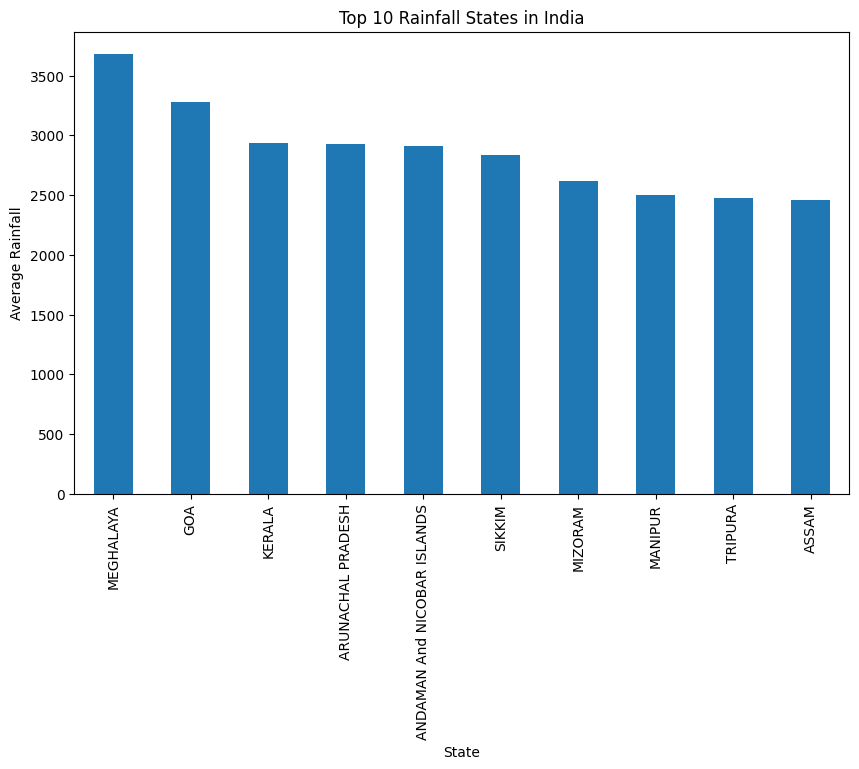

In [ ]:
import matplotlib.pyplot as plt

top_states = state_rain.head(10)

plt.figure(figsize=(10,6))
top_states.plot(kind="bar")

plt.title("Top 10 Rainfall States in India")
plt.xlabel("State")
plt.ylabel("Average Rainfall")

plt.show()

In [ ]:
df["Monsoon_Rain"] = df["JUN"] + df["JUL"] + df["AUG"] + df["SEP"]

df[["STATE_UT_NAME","DISTRICT","Monsoon_Rain"]].head()

,STATE_UT_NAME,DISTRICT,Monsoon_Rain
0,ANDAMAN And NICOBAR ISLANDS,NICOBAR,1207.2
1,ANDAMAN And NICOBAR ISLANDS,SOUTH ANDAMAN,1757.2
2,ANDAMAN And NICOBAR ISLANDS,N & M ANDAMAN,1884.4
3,ARUNACHAL PRADESH,LOHIT,1848.5
4,ARUNACHAL PRADESH,EAST SIANG,3008.4


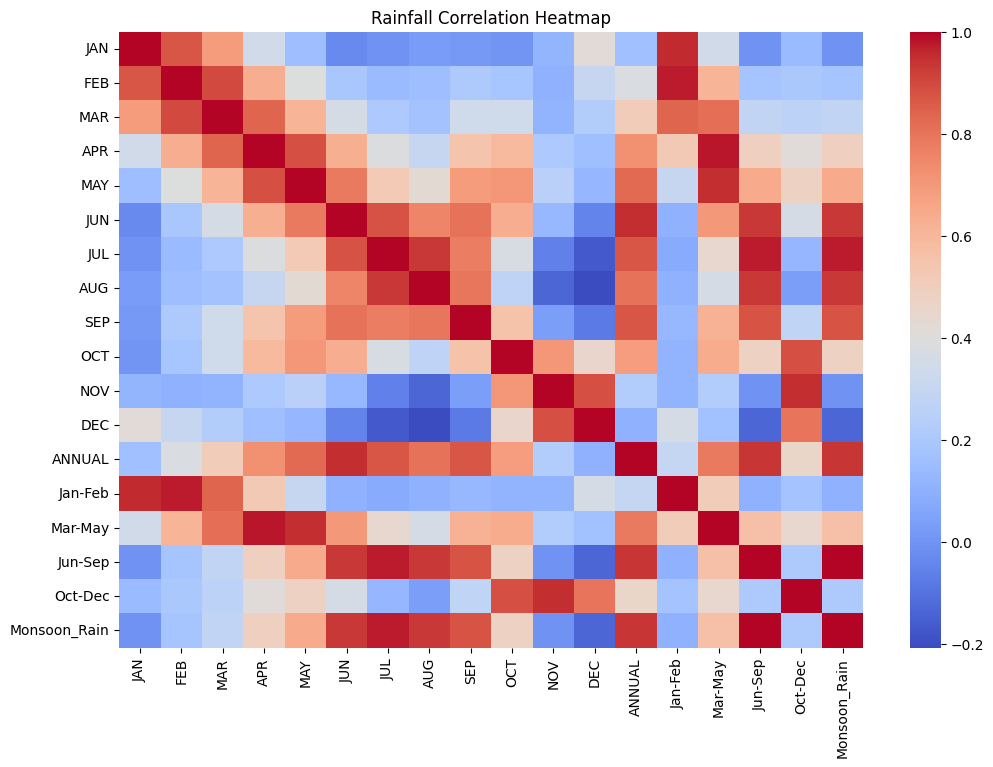

In [ ]:
import seaborn as sns

plt.figure(figsize=(12,8))

sns.heatmap(df.corr(numeric_only=True), cmap="coolwarm")

plt.title("Rainfall Correlation Heatmap")

plt.show()

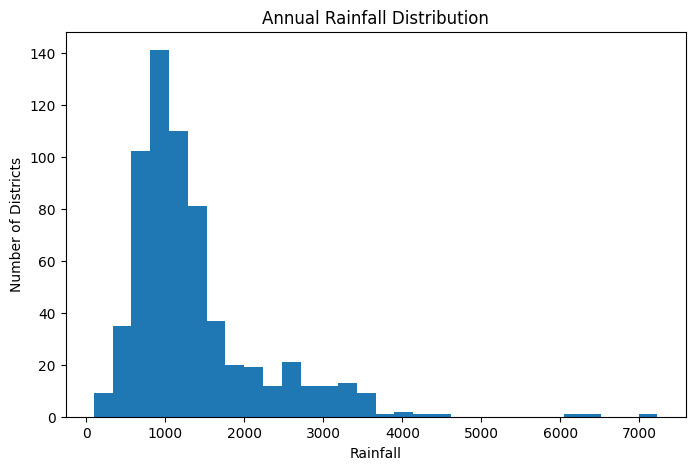

In [ ]:
plt.figure(figsize=(8,5))

plt.hist(df["ANNUAL"], bins=30)

plt.title("Annual Rainfall Distribution")
plt.xlabel("Rainfall")
plt.ylabel("Number of Districts")

plt.show()